# Tourist Origin Analysis
Assess review volume, ratings, sentiment, and themes by traveler country and region.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 150)
plt.style.use("seaborn-v0_8")

In [2]:
# Configuration
INPUT_FILE = os.getenv("INPUT_FILE", "Processed_Reviews.csv")
MIN_REVIEWS_COUNTRY = 20
MIN_REVIEWS_REGION = 10

In [3]:
# Load dataset and validate columns
df = pd.read_csv(INPUT_FILE)

print(f"Loaded: {INPUT_FILE}")
print("Shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

required_cols = ["User_Country", "User_Region", "Rating"]
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

Loaded: Processed_Reviews.csv
Shape: (16156, 41)
Columns:
['Location_Name', 'Located_City', 'Province', 'District', 'Location_Type', 'User_Locale', 'User_Country', 'User_Region', 'Travel_Date_Month', 'Travel_Date_Year', 'Published_Date_Month', 'Published_Date_Year', 'User_Contributions', 'Rating', 'Helpful_Votes', 'Review_Length', 'Title_Length', 'Rating_Class', 'Review_Delay_Days', 'Combined_Text', 'Combined_Sentiment', 'Sentiment_Score', 'Emotion', 'Dominant_Topic', 'Topic_Probability', 'Topic_Keywords', 'Review_Theme', 'Sentiment_Rating_Gap', 'Length_Bucket', 'Has_Helpful_Votes', 'Helpfulness_Ratio', 'Helpful_Bucket', 'Reviewer_Experience', 'Sentiment_Numeric', 'Location_Avg_Rating', 'Location_Review_Count', 'Location_Sentiment_Mean', 'Rank_By_Rating', 'Rank_By_Popularity', 'Popularity_Quality_Gap', 'Review_Quality_Score']


In [4]:
# Review distribution by country and region
print("=== Top 20 Countries by Review Count ===")
country_counts = df["User_Country"].value_counts().head(20)
print(country_counts)

print("\n=== Top 20 Regions by Review Count ===")
region_counts = df["User_Region"].value_counts().head(20)
print(region_counts)

=== Top 20 Countries by Review Count ===
User_Country
United Kingdom          4530
Australia               2000
India                   1625
United States            950
United Arab Emirates     432
Canada                   396
Singapore                340
Germany                  307
New Zealand              240
France                   233
China                    214
Malaysia                 202
Ireland                  142
Belgium                  142
Switzerland              140
South Africa             136
Thailand                 134
Italy                    131
Spain                    131
Sweden                   123
Name: count, dtype: int64

=== Top 20 Regions by Review Count ===
User_Region
California              225
New York                131
England                 113
Florida                  67
Texas                    38
Washington               34
District Of Columbia     33
Arizona                  28
Colorado                 26
Oregon                   25
Pennsylv

In [5]:
# Country-level rating analysis
country_rating_summary = (
    df.groupby("User_Country")
      .agg(Review_Count=("Rating", "count"), Avg_Rating=("Rating", "mean"), Rating_STD=("Rating", "std"))
      .reset_index()
)
country_rating_summary["Rating_STD"] = country_rating_summary["Rating_STD"].fillna(0)
country_rating_summary = country_rating_summary[
    country_rating_summary["Review_Count"] >= MIN_REVIEWS_COUNTRY
].sort_values(by=["Avg_Rating", "Review_Count"], ascending=[False, False])

print(f"=== Country Rating Summary (min {MIN_REVIEWS_COUNTRY} reviews) ===")
print(country_rating_summary.head(20))

=== Country Rating Summary (min 20 reviews) ===
             User_Country  Review_Count  Avg_Rating  Rating_STD
114               Ukraine            23    4.434783    0.945135
31                  Egypt            29    4.413793    0.824502
20               Cambodia            22    4.409091    1.007547
40                 Greece            52    4.384615    0.770888
93                Romania            68    4.382353    1.007871
37                Georgia            21    4.380952    0.920662
101              Slovakia            37    4.378378    0.923500
45                Hungary            31    4.354839    0.877435
89            Philippines            48    4.354167    0.862692
90                 Poland            80    4.337500    0.885091
117         United States           950    4.285263    0.939528
56                 Jordan            31    4.258065    0.773207
9              Bangladesh            53    4.245283    0.617241
106                 Spain           131    4.244275    1

In [6]:
# Region-level rating analysis
region_rating_summary = (
    df.groupby("User_Region")
      .agg(Review_Count=("Rating", "count"), Avg_Rating=("Rating", "mean"), Rating_STD=("Rating", "std"))
      .reset_index()
)
region_rating_summary["Rating_STD"] = region_rating_summary["Rating_STD"].fillna(0)
region_rating_summary = region_rating_summary[
    region_rating_summary["Review_Count"] >= MIN_REVIEWS_REGION
].sort_values(by=["Avg_Rating", "Review_Count"], ascending=[False, False])

print(f"=== Region Rating Summary (min {MIN_REVIEWS_REGION} reviews) ===")
print(region_rating_summary.head(20))

=== Region Rating Summary (min 10 reviews) ===
       User_Region  Review_Count  Avg_Rating  Rating_STD
9      Connecticut            10    4.800000    0.421637
38      New Jersey            22    4.681818    0.716231
31        Michigan            12    4.583333    0.668558
49    Pennsylvania            22    4.500000    0.740013
65        Victoria            20    4.500000    0.606977
43  North Carolina            11    4.454545    0.820200
41        New York           131    4.427481    0.832333
62           Texas            38    4.421053    0.758076
72       Wisconsin            10    4.400000    0.843274
15         Georgia            21    4.380952    0.920662
19        Illinois            16    4.375000    0.806226
36     New England            12    4.333333    0.778499
8         Colorado            26    4.307692    1.192283
30   Massachusetts            22    4.272727    0.935125
7       California           225    4.253333    0.996781
68      Washington            34    4.205

In [7]:
# Country-level sentiment analysis
if "Sentiment_Numeric" in df.columns:
    country_sentiment_summary = (
        df.groupby("User_Country")
          .agg(Review_Count=("Sentiment_Numeric", "count"), Avg_Sentiment=("Sentiment_Numeric", "mean"))
          .reset_index()
    )
    country_sentiment_summary = country_sentiment_summary[
        country_sentiment_summary["Review_Count"] >= MIN_REVIEWS_COUNTRY
    ].sort_values(by=["Avg_Sentiment", "Review_Count"], ascending=[False, False])
    print(f"=== Country Sentiment Summary (min {MIN_REVIEWS_COUNTRY} reviews) ===")
    print(country_sentiment_summary.head(20))
else:
    country_sentiment_summary = None

=== Country Sentiment Summary (min 20 reviews) ===
             User_Country  Review_Count  Avg_Sentiment
20               Cambodia            22       0.909091
37                Georgia            21       0.904762
31                  Egypt            29       0.862069
9              Bangladesh            53       0.849057
56                 Jordan            31       0.838710
8                 Bahrain            37       0.837838
89            Philippines            48       0.833333
101              Slovakia            37       0.810811
48              Indonesia            46       0.804348
84                   Oman            42       0.785714
40                 Greece            52       0.769231
117         United States           950       0.766316
45                Hungary            31       0.741935
91               Portugal            64       0.734375
115  United Arab Emirates           432       0.733796
110              Thailand           134       0.731343
78            

In [8]:
# Region-level sentiment analysis
if "Sentiment_Numeric" in df.columns:
    region_sentiment_summary = (
        df.groupby("User_Region")
          .agg(Review_Count=("Sentiment_Numeric", "count"), Avg_Sentiment=("Sentiment_Numeric", "mean"))
          .reset_index()
    )
    region_sentiment_summary = region_sentiment_summary[
        region_sentiment_summary["Review_Count"] >= MIN_REVIEWS_REGION
    ].sort_values(by=["Avg_Sentiment", "Review_Count"], ascending=[False, False])
    print(f"=== Region Sentiment Summary (min {MIN_REVIEWS_REGION} reviews) ===")
    print(region_sentiment_summary.head(20))
else:
    region_sentiment_summary = None

=== Region Sentiment Summary (min 10 reviews) ===
             User_Region  Review_Count  Avg_Sentiment
38            New Jersey            22       0.954545
15               Georgia            21       0.904762
62                 Texas            38       0.868421
35                Nevada            15       0.866667
49          Pennsylvania            22       0.863636
65              Victoria            20       0.850000
45                  Ohio            16       0.812500
48                Oregon            25       0.800000
9            Connecticut            10       0.800000
41              New York           131       0.786260
3                Arizona            28       0.785714
8               Colorado            26       0.769231
7             California           225       0.760000
12  District Of Columbia            33       0.757576
31              Michigan            12       0.750000
14               Florida            67       0.746269
68            Washington        

In [9]:
# Country vs sentiment distribution (top 10 countries)
top_countries = df["User_Country"].value_counts().head(10).index

country_sentiment_crosstab = pd.crosstab(
    df[df["User_Country"].isin(top_countries)]["User_Country"],
    df[df["User_Country"].isin(top_countries)]["Combined_Sentiment"]
)

print("\n=== Sentiment Distribution in Top 10 Countries ===")
print(country_sentiment_crosstab)

country_sentiment_pct = pd.crosstab(
    df[df["User_Country"].isin(top_countries)]["User_Country"],
    df[df["User_Country"].isin(top_countries)]["Combined_Sentiment"],
    normalize="index"
).round(3) * 100

print("\n=== Sentiment Percentage in Top 10 Countries ===")
print(country_sentiment_pct)


=== Sentiment Distribution in Top 10 Countries ===
Combined_Sentiment    NEGATIVE  NEUTRAL  POSITIVE
User_Country                                     
Australia                  191      218      1591
Canada                      43       43       310
France                      26       18       189
Germany                     32       35       240
India                      128      235      1262
New Zealand                 22       32       186
Singapore                   34       47       259
United Arab Emirates        35       45       352
United Kingdom             470      478      3582
United States               59      104       787

=== Sentiment Percentage in Top 10 Countries ===
Combined_Sentiment    NEGATIVE  NEUTRAL  POSITIVE
User_Country                                     
Australia                  9.6     10.9      79.6
Canada                    10.9     10.9      78.3
France                    11.2      7.7      81.1
Germany                   10.4     11.4      78.

In [10]:
# Country vs review theme (top 10 countries)
if "Review_Theme" in df.columns:
    country_theme_crosstab = pd.crosstab(
        df[df["User_Country"].isin(top_countries)]["User_Country"],
        df[df["User_Country"].isin(top_countries)]["Review_Theme"]
    )
    print("\n=== Review Theme Distribution in Top 10 Countries ===")
    print(country_theme_crosstab)
else:
    country_theme_crosstab = None


=== Review Theme Distribution in Top 10 Countries ===
Review_Theme          Crowding & Pricing  Cultural Experience  \
User_Country                                                    
Australia                             48                   96   
Canada                                 7                   28   
France                                 2                   15   
Germany                                6                   16   
India                                 27                  100   
New Zealand                            6                   14   
Singapore                              4                   14   
United Arab Emirates                  13                   16   
United Kingdom                        94                  340   
United States                         23                   50   

Review_Theme          Food & Hospitality  Other  Scenery  Service Quality  \
User_Country                                                                
Australia 

In [11]:
# Top and bottom origin groups by rating
top_countries_by_rating = country_rating_summary.head(10)
bottom_countries_by_rating = country_rating_summary.tail(10)

print("\n=== Top Countries by Average Rating ===")
print(top_countries_by_rating)

print("\n=== Bottom Countries by Average Rating ===")
print(bottom_countries_by_rating)


=== Top Countries by Average Rating ===
    User_Country  Review_Count  Avg_Rating  Rating_STD
114      Ukraine            23    4.434783    0.945135
31         Egypt            29    4.413793    0.824502
20      Cambodia            22    4.409091    1.007547
40        Greece            52    4.384615    0.770888
93       Romania            68    4.382353    1.007871
37       Georgia            21    4.380952    0.920662
101     Slovakia            37    4.378378    0.923500
45       Hungary            31    4.354839    0.877435
89   Philippines            48    4.354167    0.862692
90        Poland            80    4.337500    0.885091

=== Bottom Countries by Average Rating ===
     User_Country  Review_Count  Avg_Rating  Rating_STD
100     Singapore           340    4.035294    1.072004
27        Croatia            35    4.028571    1.224402
12        Belgium           142    4.014085    1.071791
108        Sweden           123    4.000000    1.101415
102      Slovenia            3

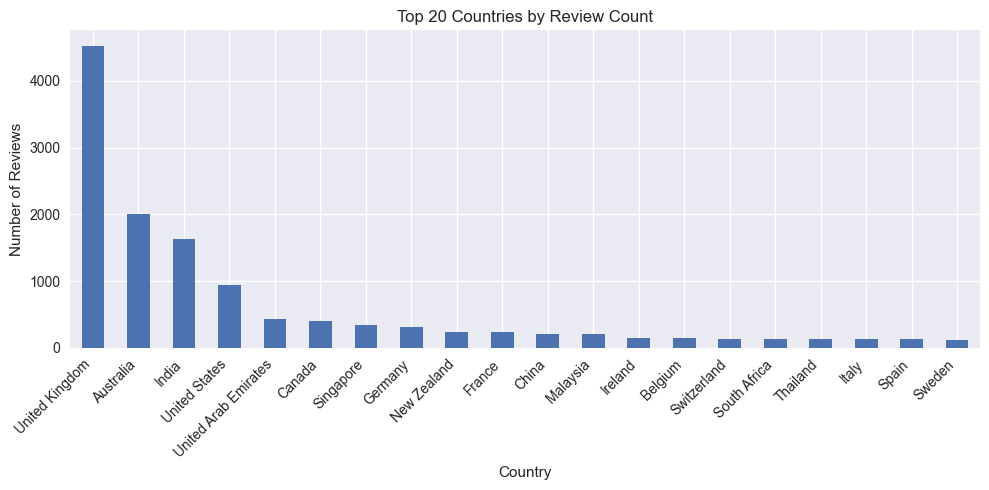

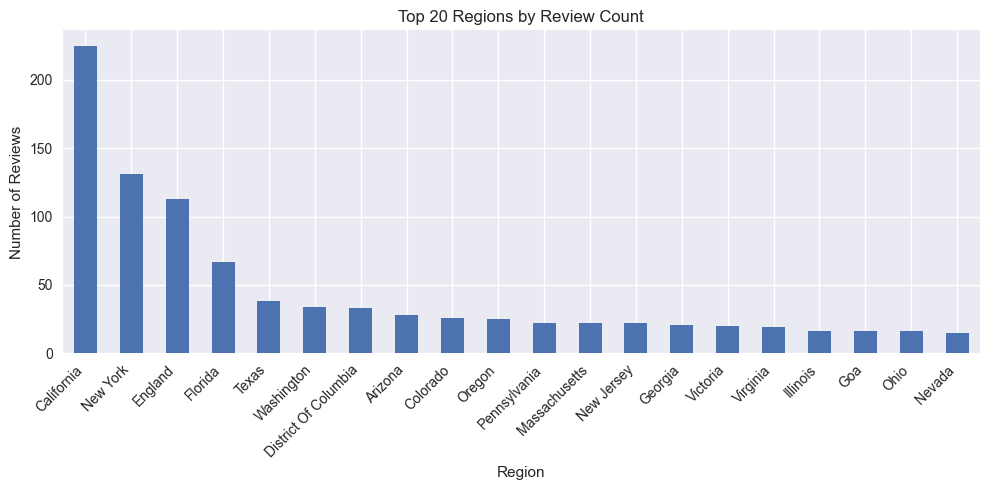

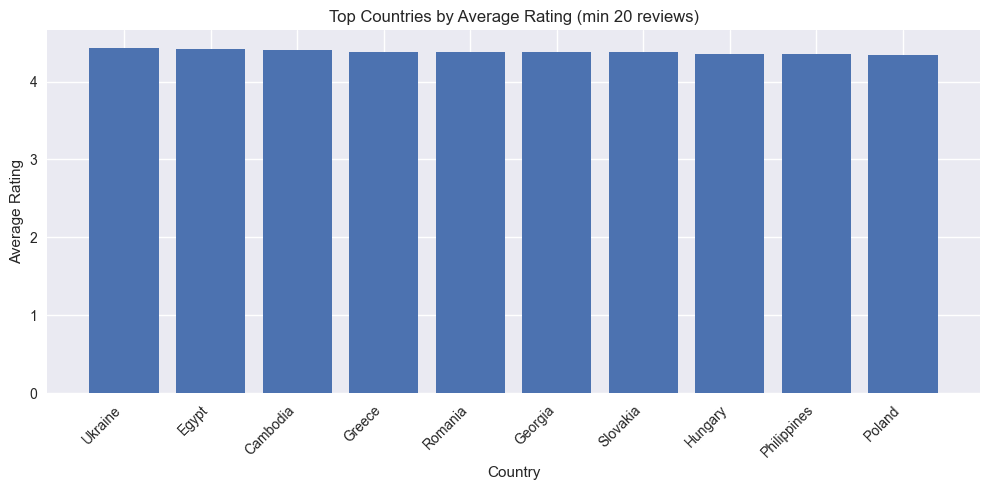

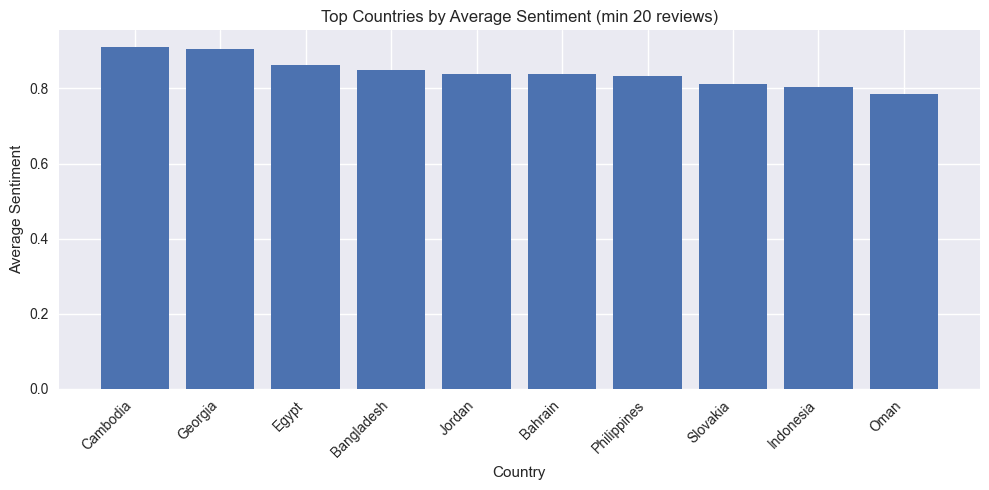

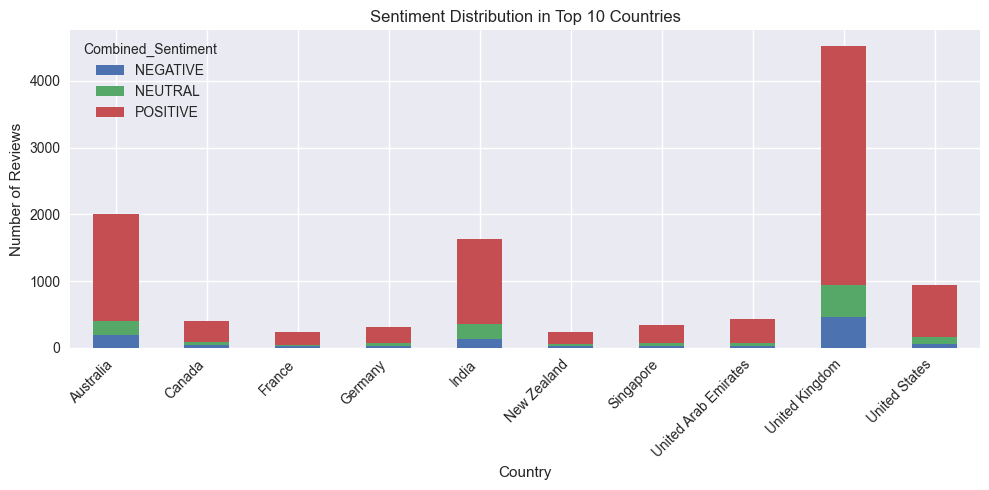

In [12]:
# Plots
plt.figure(figsize=(10, 5))
country_counts.plot(kind="bar")
plt.title("Top 20 Countries by Review Count")
plt.xlabel("Country")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
region_counts.plot(kind="bar")
plt.title("Top 20 Regions by Review Count")
plt.xlabel("Region")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

if not country_rating_summary.empty:
    plt.figure(figsize=(10, 5))
    plt.bar(top_countries_by_rating["User_Country"], top_countries_by_rating["Avg_Rating"])
    plt.title(f"Top Countries by Average Rating (min {MIN_REVIEWS_COUNTRY} reviews)")
    plt.xlabel("Country")
    plt.ylabel("Average Rating")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

if country_sentiment_summary is not None and not country_sentiment_summary.empty:
    plt.figure(figsize=(10, 5))
    plt.bar(country_sentiment_summary.head(10)["User_Country"], country_sentiment_summary.head(10)["Avg_Sentiment"])
    plt.title(f"Top Countries by Average Sentiment (min {MIN_REVIEWS_COUNTRY} reviews)")
    plt.xlabel("Country")
    plt.ylabel("Average Sentiment")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

if not country_sentiment_crosstab.empty:
    country_sentiment_crosstab.plot(kind="bar", stacked=True, figsize=(10, 5))
    plt.title("Sentiment Distribution in Top 10 Countries")
    plt.xlabel("Country")
    plt.ylabel("Number of Reviews")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

In [13]:
# Save outputs
country_rating_summary.to_csv("country_rating_summary.csv", index=False)
region_rating_summary.to_csv("region_rating_summary.csv", index=False)
country_counts.to_csv("country_review_counts.csv")
region_counts.to_csv("region_review_counts.csv")
country_sentiment_crosstab.to_csv("country_sentiment_crosstab.csv")
country_sentiment_pct.to_csv("country_sentiment_percentage.csv")

if country_sentiment_summary is not None:
    country_sentiment_summary.to_csv("country_sentiment_summary.csv", index=False)

if region_sentiment_summary is not None:
    region_sentiment_summary.to_csv("region_sentiment_summary.csv", index=False)

if country_theme_crosstab is not None:
    country_theme_crosstab.to_csv("country_theme_distribution.csv")

print("✅ Tourist origin analysis complete.")
print("Saved files:")
print("- country_rating_summary.csv")
print("- region_rating_summary.csv")
print("- country_review_counts.csv")
print("- region_review_counts.csv")
print("- country_sentiment_crosstab.csv")
print("- country_sentiment_percentage.csv")
if country_sentiment_summary is not None:
    print("- country_sentiment_summary.csv")
if region_sentiment_summary is not None:
    print("- region_sentiment_summary.csv")
if country_theme_crosstab is not None:
    print("- country_theme_distribution.csv")

✅ Tourist origin analysis complete.
Saved files:
- country_rating_summary.csv
- region_rating_summary.csv
- country_review_counts.csv
- region_review_counts.csv
- country_sentiment_crosstab.csv
- country_sentiment_percentage.csv
- country_sentiment_summary.csv
- region_sentiment_summary.csv
- country_theme_distribution.csv
